# Regression inference on different data: wealth & longevity

*Part 2 · Lesson 18 · another dataset  ·  data: Gapminder (log GDP vs life expectancy)*

*↩ A companion to [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb).*

**↩ Back:** [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](18-regression-inference~the-code.ipynb)

In the **relationships data lesson** we asked whether richer countries live longer, and learned a lesson
about *shape*: the raw wealth-vs-lifespan cloud was **curved**, a straight line misfit it in a patterned
arch, and a **log transform** of wealth straightened everything out. That left us with a clean,
believable straight-line fit and a memorable slope — about **17 more years of life for every tenfold
increase in income**.

But that 17 came from *one* snapshot: the 142 countries that happened to exist in 2007. This lesson asks
the honest follow-up question: **is that slope real, or could the true relationship be flat and we just
got a lucky-looking sample?** We'll turn the descriptive line into an **inference** — a standard error
for the slope, a **t-test** of "no relationship at all," a **confidence interval**, the **regression
table** that hands you all of it, and the **residual diagnostics** that decide whether the numbers can be
trusted. The headline difference from the core lesson: here we do the inference on a model whose **shape
we already validated** with a log transform. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
sl.use_course_style()

GAPMINDER_URL = 'https://raw.githubusercontent.com/kirenz/datasets/master/gapminder.csv'
gap = sl.load_csv('gapminder.csv', url=GAPMINDER_URL)

# One year, so each country appears exactly once (a clean cross-section).
g07 = gap[gap['year'] == 2007].copy()

# The transform we EARNED in the relationships data lesson: log10 of wealth
# straightened a curved relationship. We do all inference on this fitted shape.
g07['logwealth'] = np.log10(g07['gdpPercap'])    # 3 = 1,000 dollars, 4 = 10,000 dollars

print(f'{len(g07)} countries in 2007')
print(f'GDP per capita ranges from {g07["gdpPercap"].min():,.0f} to {g07["gdpPercap"].max():,.0f} dollars/person')
print(f'life expectancy ranges from {g07["lifeExp"].min():.1f} to {g07["lifeExp"].max():.1f} years')
g07[['country', 'gdpPercap', 'logwealth', 'lifeExp']].head()

142 countries in 2007
GDP per capita ranges from 278 to 49,357 dollars/person
life expectancy ranges from 39.6 to 82.6 years


,country,gdpPercap,logwealth,lifeExp
11,Afghanistan,974.580338,2.988818,43.828
23,Albania,5937.029526,3.773569,76.423
35,Algeria,6223.367465,3.794025,72.301
47,Angola,4797.231267,3.680991,42.731
59,Argentina,12779.379640,4.106510,75.320


## 1) The slope is an estimate of something we can't see

When we fit the straight line $\hat{y} = b_0 + b_1 x$ — here with $y$ = life expectancy and
$x = \log_{10}(\text{GDP per capita})$ — the slope $b_1$ is computed from the **142 countries in our
data**. But imagine the larger, fuzzier reality those countries are a snapshot of: the long-run
relationship between wealth and lifespan in the world. There is some **true** underlying slope in that
world,

$$y = \beta_0 + \beta_1 x + \varepsilon,$$

where $\beta_1$ (Greek "beta-one") is the **population slope** — the real years-per-tenfold-increase that
we never get to observe directly — and $\varepsilon$ is the random scatter of each country around the
line. Our sample slope $b_1$ is an **estimate** of $\beta_1$, in exactly the way a sample mean $\bar{x}$
estimates a population mean $\mu$ (see the **estimation** lesson). A different snapshot of the world —
different countries, a different year — would give a slightly different $b_1$. So $b_1$ has its own
**sampling distribution** and its own **standard error**: the typical distance between our estimate and
the truth.

Let's refit the validated log line and put our numbers in front of us.

sample slope     b1 = 16.59 years per tenfold increase in GDP/person
sample intercept b0 = 4.95 years
correlation       r = 0.809    (R^2 = 0.654)


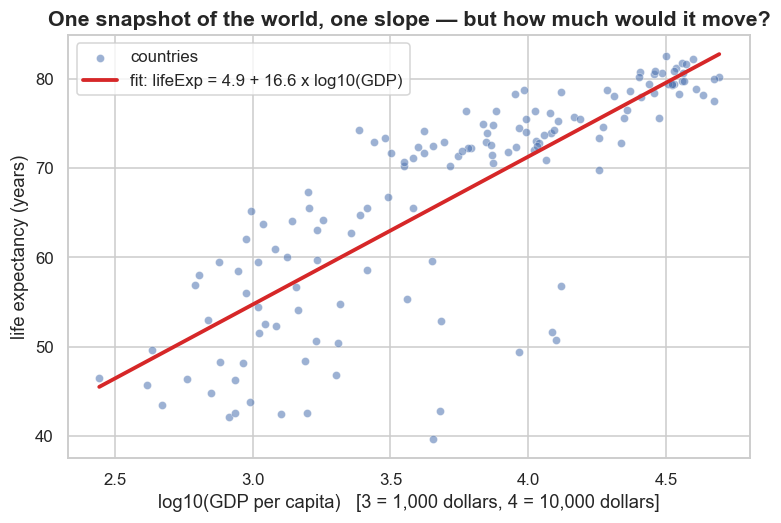

In [2]:
x = g07['logwealth'].to_numpy()       # wealth on a log10 ruler (the validated predictor)
y = g07['lifeExp'].to_numpy()         # life expectancy (years)

b1, b0 = np.polyfit(x, y, 1)          # numpy returns [slope, intercept]
r = np.corrcoef(x, y)[0, 1]
print(f'sample slope     b1 = {b1:.2f} years per tenfold increase in GDP/person')
print(f'sample intercept b0 = {b0:.2f} years')
print(f'correlation       r = {r:.3f}    (R^2 = {r**2:.3f})')

line_x = np.array([x.min(), x.max()])
fig, ax = plt.subplots()
ax.scatter(x, y, s=28, alpha=0.55, color='#4c72b0', edgecolor='white', lw=0.4, label='countries')
ax.plot(line_x, b0 + b1 * line_x, color='#d62728', lw=2.5,
        label=f'fit: lifeExp = {b0:.1f} + {b1:.1f} x log10(GDP)')
ax.set_xlabel('log10(GDP per capita)   [3 = 1,000 dollars, 4 = 10,000 dollars]')
ax.set_ylabel('life expectancy (years)')
ax.set_title('One snapshot of the world, one slope — but how much would it move?')
ax.legend(); plt.show()

## 2) Watch the slope wobble — the sampling distribution, by simulation

Here is the simulation-first heart of the lesson. We don't have other snapshots of the world lying
around, so we **manufacture** them by **bootstrapping**: draw a new dataset of the same size by sampling
countries **with replacement** from the 142 we have, re-fit the log line, and record the slope. Repeat
thousands of times. The spread of those slopes *is* the sampling distribution of $b_1$, and its standard
deviation *is* the standard error of the slope — no formula needed.

(Why with replacement? It treats our 142 countries as a stand-in for the wider reality and re-draws from
them, mimicking the act of collecting a fresh batch. The **bootstrap & permutation** lesson is devoted
to this trick; here we just use it.)

In [3]:
rng = np.random.default_rng(20)       # change this seed to get a different batch of bootstraps
n_boot = 4000
n = len(g07)
idx = np.arange(n)

boot_slopes = np.empty(n_boot)
for i in range(n_boot):
    take = rng.choice(idx, size=n, replace=True)     # a resampled set of 142 countries
    s, _ = np.polyfit(x[take], y[take], 1)
    boot_slopes[i] = s

boot_se = boot_slopes.std(ddof=1)
print(f'Across {n_boot:,} resampled datasets:')
print(f'  average slope          = {boot_slopes.mean():.2f} years/tenfold   (centered on our b1 = {b1:.2f})')
print(f'  std of the slopes (SE) = {boot_se:.2f} years/tenfold   <- the bootstrap standard error')

Across 4,000 resampled datasets:
  average slope          = 16.59 years/tenfold   (centered on our b1 = 16.59)
  std of the slopes (SE) = 0.78 years/tenfold   <- the bootstrap standard error


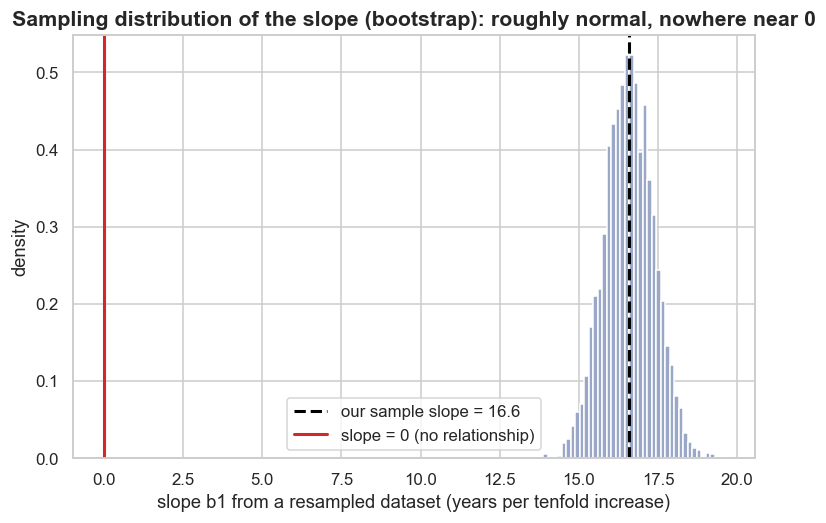

In [4]:
fig, ax = plt.subplots()
ax.hist(boot_slopes, bins=40, color='#9aa7c7', edgecolor='white', density=True)
ax.axvline(b1, color='black', ls='--', lw=2, label=f'our sample slope = {b1:.1f}')
ax.axvline(0, color='#d62728', lw=2, label='slope = 0 (no relationship)')
ax.set_xlabel('slope b1 from a resampled dataset (years per tenfold increase)')
ax.set_ylabel('density')
ax.set_title('Sampling distribution of the slope (bootstrap): roughly normal, nowhere near 0')
ax.legend(); plt.show()

Two things to notice. First, the cloud of slopes is **roughly bell-shaped and centered on our $b_1$** —
the same Central Limit Theorem magic that made sample *means* normal also makes sample *slopes* normal.
Second, the whole hill sits **a long way to the right of zero** (the red line). A slope of 0 would mean
"a country's wealth tells you nothing about its life expectancy." That value isn't just unlikely — it's
**off the chart entirely**, far from any slope our resampling ever produced. Already a strong hint that
the relationship is real, not luck.

### A bootstrap confidence interval for the slope

A 95% confidence interval is just the **middle 95%** of that bootstrap pile — cut off the lowest 2.5%
and the highest 2.5%.

In [5]:
ci_lo, ci_hi = np.percentile(boot_slopes, [2.5, 97.5])
print(f'95% bootstrap CI for the slope: ({ci_lo:.1f}, {ci_hi:.1f}) years per tenfold increase')
print(f'Does this interval contain 0 (no relationship)?  {"yes" if ci_lo <= 0 <= ci_hi else "NO"}')
print('\nPlain English: across plausible snapshots of the world, a tenfold increase in income')
print(f'goes with somewhere between about {ci_lo:.0f} and {ci_hi:.0f} more years of life. Zero is not close.')

95% bootstrap CI for the slope: (15.1, 18.1) years per tenfold increase
Does this interval contain 0 (no relationship)?  NO

Plain English: across plausible snapshots of the world, a tenfold increase in income
goes with somewhere between about 15 and 18 more years of life. Zero is not close.


## 3) The textbook formula — and reading the regression table

Statisticians don't bootstrap every time; there's a classic formula for the standard error of the
slope,

$$\text{SE}(b_1) = \frac{s_e}{\sqrt{\sum (x_i-\bar{x})^2}},$$

where $s_e$ is the spread of the residuals. With it you build a **t-statistic** and test the null
hypothesis (see the **hypothesis-testing** lesson):

$$H_0:\ \beta_1 = 0 \quad(\text{wealth has no linear effect on lifespan}) \qquad
  t = \frac{b_1 - 0}{\text{SE}(b_1)},\quad df = n-2.$$

The **alternative** is $H_a:\ \beta_1 \neq 0$ — that there *is* some linear effect, in either direction.
`statsmodels` does all of this and prints a standard **regression table**. Let's read it line by line.

In [6]:
model = smf.ols('lifeExp ~ logwealth', data=g07).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                lifeExp   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     265.2
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           4.12e-34
Time:                        09:54:40   Log-Likelihood:                -479.26
No. Observations:                 142   AIC:                             962.5
Df Residuals:                     140   BIC:                             968.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9496      3.858      1.283      0.2

The block you care about is the middle table. For the **`logwealth`** row:

- **`coef` = 16.59** — the slope $b_1$: about **16.6 more years of life per tenfold increase** in GDP per
  person (and `Intercept` = the $b_0$ we already saw — the predicted lifespan at $\log_{10}(\text{GDP})=0$,
  i.e. 1 dollar per person, an extrapolation far outside the data that only anchors the line's height).
- **`std err` = 1.02** — the textbook $\text{SE}(b_1)$: how much $b_1$ would wobble between snapshots.
- **`t` = 16.28** — the slope is **16 standard errors away from 0**. Enormous.
- **`P>|t|` = 0.000** — the **p-value**: *if* the true slope were exactly 0, the chance of seeing a sample
  slope this far from 0 is essentially nil (it's about $4\times10^{-34}$, which the table rounds to
  0.000). We reject "no relationship" overwhelmingly.
- **`[0.025  0.975]` = (14.57, 18.60)** — the textbook **95% confidence interval** for $\beta_1$.

And in the header, **`R-squared` = 0.654**: log-wealth alone explains about **two-thirds** of the
variation in life expectancy across countries (the rest is health systems, conflict, disease, history,
...). For a one-predictor regression $R^2 = r^2$, exactly as in the relationships lesson — and recall
the *raw* GDP fit only reached $R^2 \approx 0.46$, so validating the shape first bought us real
explanatory power.

Let's pull those numbers out as values, then rebuild the confidence interval by hand to show the table
is just the formula $b_1 \pm t^{*}\,\text{SE}(b_1)$ in disguise.

In [7]:
b1_hat   = model.params['logwealth']
se_b1    = model.bse['logwealth']
t_stat   = model.tvalues['logwealth']
p_value  = model.pvalues['logwealth']
df       = int(model.df_resid)             # n - 2 = 142 - 2 = 140

print(f'slope b1        = {b1_hat:.2f} years per tenfold increase')
print(f'SE(b1)          = {se_b1:.3f}')
print(f't = b1 / SE(b1) = {t_stat:.2f}   (df = {df})')
print(f'p-value         = {p_value:.2e}   <- far smaller than 0.05; the slope is real')

# Rebuild the 95% CI by hand from the t multiplier:
tstar = stats.t.ppf(0.975, df=df)          # ~1.98 for this many degrees of freedom
lo = b1_hat - tstar * se_b1
hi = b1_hat + tstar * se_b1
print(f'\nt* (95%, df={df}) = {tstar:.3f}')
print(f'hand-built 95% CI = ({lo:.2f}, {hi:.2f})')
print(f'statsmodels   CI = ({model.conf_int().loc["logwealth", 0]:.2f}, {model.conf_int().loc["logwealth", 1]:.2f})   <- identical')

slope b1        = 16.59 years per tenfold increase
SE(b1)          = 1.019
t = b1 / SE(b1) = 16.28   (df = 140)
p-value         = 4.12e-34   <- far smaller than 0.05; the slope is real

t* (95%, df=140) = 1.977
hand-built 95% CI = (14.57, 18.60)
statsmodels   CI = (14.57, 18.60)   <- identical


**Interpreting the interval in real words:** we are 95% confident that, across the wider reality these
countries represent, each **tenfold** increase in income (say from 1,000 to 10,000 dollars per person)
is associated with between about **14.6 and 18.6 more years** of life expectancy. (As always with
confidence intervals — see the **confidence-interval flagship** — the 95% is a property of the *method's
long-run hit rate*, not a probability about this one interval.) Because the entire interval is
**positive and far from 0**, "no relationship" is simply not a credible story.

### Do the two methods agree?

We now have two confidence intervals for the same slope: the **bootstrap** one we simulated, and the
**formula** one from statsmodels. Honest methods should roughly agree when the model's conditions hold —
let's check.

In [8]:
print('95% CI for the slope, two ways:')
print(f'  bootstrap (simulated)   : ({ci_lo:6.2f}, {ci_hi:6.2f})   width = {ci_hi - ci_lo:5.2f}')
print(f'  statsmodels (formula)   : ({lo:6.2f}, {hi:6.2f})   width = {hi - lo:5.2f}')
print()
print(f'  bootstrap SE = {boot_se:.2f}      formula SE = {se_b1:.2f}')
print('\nDifferent machinery, same verdict: both CIs sit far from 0 and put the slope near 16-17.')
print('They are close but NOT identical -- here the bootstrap interval comes out a bit narrower.')

95% CI for the slope, two ways:
  bootstrap (simulated)   : ( 15.09,  18.11)   width =  3.02
  statsmodels (formula)   : ( 14.57,  18.60)   width =  4.03

  bootstrap SE = 0.78      formula SE = 1.02

Different machinery, same verdict: both CIs sit far from 0 and put the slope near 16-17.
They are close but NOT identical -- here the bootstrap interval comes out a bit narrower.


The two intervals land in the **same ballpark** but are **not identical**: both sit far from 0 and both put
the slope at roughly 15–19 years per tenfold increase — yet here the bootstrap interval comes out a little
**narrower** than the textbook one (its standard error is smaller). That's the honest picture, and it is the
real lesson: a simulation and a century-old formula, built in completely different ways, reach the **same
verdict** — a strong, clearly-nonzero slope. They needn't match to the decimal. The textbook formula leans
on assumptions (roughly constant scatter, roughly normal residuals) that the bootstrap quietly skips, so
small gaps between the two are exactly what you'd expect. (In the core lesson on Ames the gap ran the
*other* way — there an honest bootstrap came out much **wider** than the formula, a red flag that exposed
the famous Ames "funnel" where the textbook SE was too optimistic.) When two methods this different agree
on the substance, the conclusion is trustworthy — but to see *why* the formula is believable here, we open
up the **residuals**.

## 4) Residual diagnostics — checking the fine print

The slope estimate $b_1$ is trustworthy on its own, but the **standard error, t, p-value, and CI** all
ride on a few assumptions about the residuals $e_i = y_i - \hat{y}_i$. Two pictures check most of them —
and because we already validated the *shape* with a log transform in the relationships lesson, we expect
these to come out clean. Let's confirm.

### Diagnostic 1 — residuals vs. fitted (the shape & funnel test)

Plot each country's residual against its predicted lifespan. What you **want** is a shapeless, horizontal
band of constant thickness around 0. A **curve** (an arch) would signal the straight line is the wrong
shape — exactly the misfit the *raw*-GDP fit showed in the relationships lesson. A **funnel** that fans
open would signal **heteroscedasticity** ("unequal scatter"), which breaks the textbook standard errors.

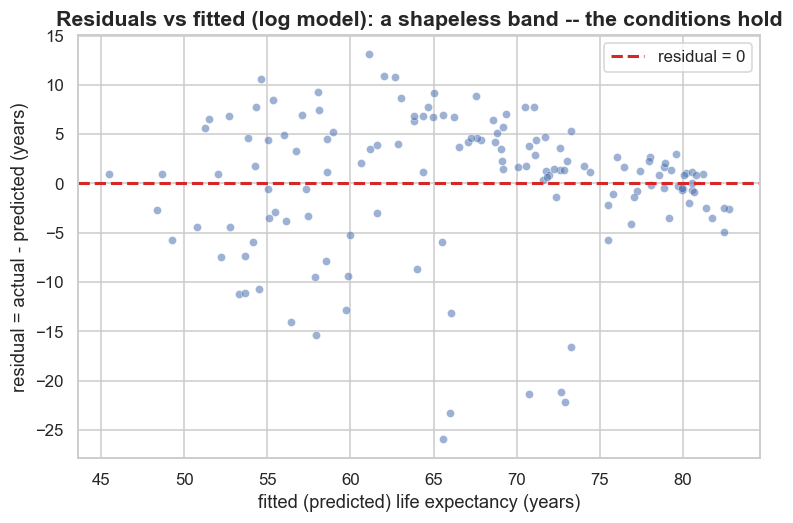

Residuals always average to ~0: mean = -0.000 years
No arch, no funnel -- just scatter. The straight-line-on-log model fits.


In [9]:
fitted = model.fittedvalues
resid = model.resid

fig, ax = plt.subplots()
ax.scatter(fitted, resid, s=28, alpha=0.55, color='#4c72b0', edgecolor='white', lw=0.4)
ax.axhline(0, color='#d62728', lw=2, ls='--', label='residual = 0')
ax.set_xlabel('fitted (predicted) life expectancy (years)')
ax.set_ylabel('residual = actual - predicted (years)')
ax.set_title('Residuals vs fitted (log model): a shapeless band -- the conditions hold')
ax.legend(); plt.show()

print(f'Residuals always average to ~0: mean = {resid.mean():.3f} years')
print('No arch, no funnel -- just scatter. The straight-line-on-log model fits.')

This is what "the model fits" looks like: a **shapeless cloud** hovering around 0, with **no arch** and
**no funnel**. Compare it to the relationships data lesson, where the *raw* GDP fit's residuals bent into
a clear arch (∩) — that bend was the straight line confessing it was the wrong shape, and the log
transform is exactly what erased it. Doing inference on the **validated** model means the residual plot
backs us up instead of warning us off. (There's a hint of slightly wider scatter among the poorest, very
low-lifespan countries, but it's mild — not the dramatic, systematic funnel that wrecked the Ames
formula.) That reasonably clean band is *why* the textbook formula is believable here — and why the
bootstrap, which assumes none of that, lands in the same ballpark back in section 3.

### Diagnostic 2 — the normal Q-Q plot of residuals

The second assumption behind the t-based p-value is that the residuals are roughly **normally
distributed**. A **Q-Q (quantile-quantile) plot** checks this by sorting the residuals and plotting them
against the values a perfect normal would produce. If the residuals are normal, the dots fall on a
straight diagonal; **bent ends** reveal heavy tails or skew — a few countries the line misses by more
than a normal model expects.

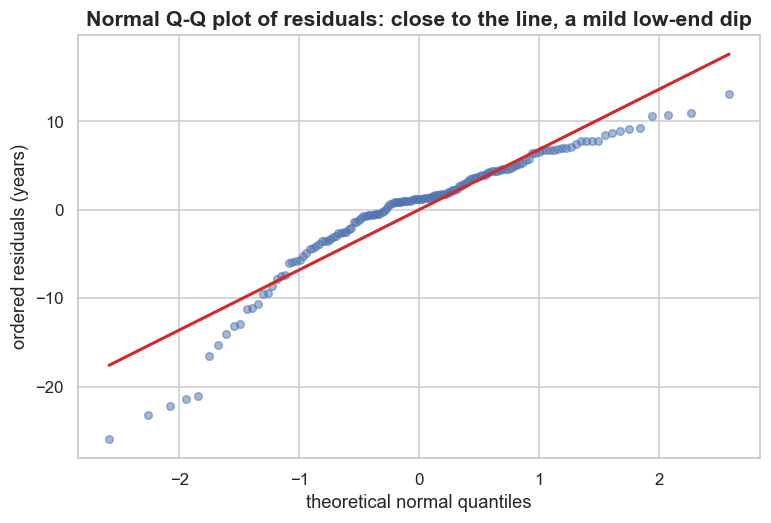

In [10]:
fig, ax = plt.subplots()
stats.probplot(resid, dist='norm', plot=ax)     # builds the Q-Q plot
ax.get_lines()[0].set(marker='o', markersize=5, alpha=0.5, color='#4c72b0')   # the points
ax.get_lines()[1].set(color='#d62728', lw=2)                                  # the ideal line
ax.set_title('Normal Q-Q plot of residuals: close to the line, a mild low-end dip')
ax.set_xlabel('theoretical normal quantiles'); ax.set_ylabel('ordered residuals (years)')
plt.show()

Most of the cloud hugs the diagonal nicely, with only a **mild dip at the lower-left**: a handful of
countries (think those hit hard by conflict or the HIV/AIDS epidemic in 2007) lived several years *less*
than the line predicts, giving a slightly heavy lower tail. This is far gentler than the strong upward
curl of house prices in the core lesson. With **142** countries the Central Limit Theorem keeps the test
for the *slope* robust to this mild departure — large samples forgive non-normal residuals. The
combination — a flat residual band **and** a near-straight Q-Q plot — means the regression table's
standard error, t, p-value, and CI are all trustworthy here.

## 5) Putting it together — the slope is real, but "real" is not "causal"

Let's collect the verdict in one place, then sound the warning the relationships lesson ended on.

In [11]:
print('=== Inference for the slope of lifeExp on log10(GDP per capita), 2007 ===\n')
print(f'  point estimate  b1 = {b1_hat:.2f} years per tenfold increase in income')
print(f'  standard error     = {se_b1:.2f}')
print(f'  t (H0: slope = 0)  = {t_stat:.1f}   on {df} degrees of freedom')
print(f'  p-value            = {p_value:.1e}   (overwhelmingly significant)')
print(f'  95% CI for slope   = ({lo:.1f}, {hi:.1f}) years per tenfold increase')
print(f'  R^2                = {model.rsquared:.3f}   (log-wealth explains ~{model.rsquared*100:.0f}% of lifespan)')
print('\n  Verdict: the slope is far too strong, and far too precisely pinned down,')
print('  to be a fluke of which countries happened to exist in 2007.')

=== Inference for the slope of lifeExp on log10(GDP per capita), 2007 ===

  point estimate  b1 = 16.59 years per tenfold increase in income
  standard error     = 1.02
  t (H0: slope = 0)  = 16.3   on 140 degrees of freedom
  p-value            = 4.1e-34   (overwhelmingly significant)
  95% CI for slope   = (14.6, 18.6) years per tenfold increase
  R^2                = 0.654   (log-wealth explains ~65% of lifespan)

  Verdict: the slope is far too strong, and far too precisely pinned down,
  to be a fluke of which countries happened to exist in 2007.


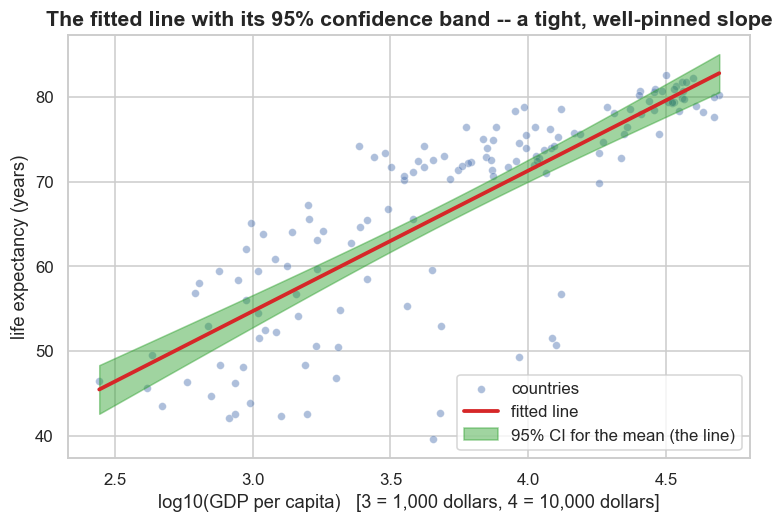

In [12]:
# Draw the fitted line with its 95% confidence band for the MEAN response,
# so the precision of the slope is something you can SEE.
grid = pd.DataFrame({'logwealth': np.linspace(x.min(), x.max(), 200)})
pf = model.get_prediction(grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots()
ax.scatter(x, y, s=26, alpha=0.45, color='#4c72b0', edgecolor='white', lw=0.4, label='countries')
ax.plot(grid['logwealth'], pf['mean'], color='#d62728', lw=2.5, label='fitted line')
ax.fill_between(grid['logwealth'], pf['mean_ci_lower'], pf['mean_ci_upper'],
                color='#2ca02c', alpha=0.45, label='95% CI for the mean (the line)')
ax.set_xlabel('log10(GDP per capita)   [3 = 1,000 dollars, 4 = 10,000 dollars]')
ax.set_ylabel('life expectancy (years)')
ax.set_title('The fitted line with its 95% confidence band -- a tight, well-pinned slope')
ax.legend(loc='lower right'); plt.show()

The green band hugging the line is thin — with 142 countries the *height* of the line, and therefore its
slope, is known well. That tight band is the visual twin of the small standard error: this is a
**precisely estimated** relationship.

**And yet — correlation is still not causation.** A slope that is real, strong, and precisely pinned down
is *still not proof* that getting richer **causes** people to live longer. Exactly as the relationships
data lesson warned, wealth and longevity are tangled up with a web of **shared causes**: richer countries
tend to have better **health systems**, cleaner **water and sanitation**, more **education** and
**vaccination**. A confounder like "quality of public health" can push *both* GDP and life expectancy up
together, manufacturing a strong, significant slope **without** wealth being the direct cause. Inference
sharpens *how confidently we can describe the association* (very); it does **not** upgrade an association
into a cause. The honest phrasing stays: wealth is **strongly and significantly associated with** longer
life — not proven to cause it.

## Now you try

Predict what will happen *before* you run each change:

1. **Re-roll the bootstrap.** Change `np.random.default_rng(20)` to another seed and re-run sections 2-3.
   Does the bootstrap CI for the slope shift much? Do *any* of your 4,000 resampled slopes ever fall at
   or below 0? (They essentially never will — that's what $p \approx 4\times10^{-34}$ feels like.)

2. **Skip the transform — do inference on the WRONG shape.** Fit the *raw*-GDP model and read its table:

       print(smf.ols('lifeExp ~ gdpPercap', data=g07).fit().summary())

   Its slope is also "significant" (tiny p-value) — but plot *its* residuals vs fitted. You'll see the
   **arch** from the relationships lesson return. Moral: a tiny p-value does **not** mean the model is
   the right shape; always check the residuals.

3. **Natural log instead of log10.** Refit with `g07['lnwealth'] = np.log(g07['gdpPercap'])` and
   `smf.ols('lifeExp ~ lnwealth', ...)`. Does the **p-value** change? Does the **slope** change? (The
   evidence is identical; only the slope's *units* change — now it's "years per *e*-fold increase.")

4. **Pick a different year.** Rebuild `g07` for `1952` or `1977` (set the `year` filter). Is the
   log-wealth slope still strongly significant? Is it bigger or smaller than 2007's 16.6? (Tip:
   `gap['year'].unique()` lists the available years.)

## What you learned

- The sample slope $b_1$ is an **estimate** of an unseen **population slope** $\beta_1$; like any estimate
  it has a **sampling distribution** and a **standard error** — here estimated on the **log-wealth** model
  whose shape we validated in the relationships lesson.
- **Resampling (bootstrap)** builds that sampling distribution directly: re-fit the line on many
  resampled sets of countries and the spread of slopes *is* the standard error (about 0.8 of a year here) —
  no formula required.
- The **regression table** (`smf.ols(...).fit().summary()`) hands you the slope (`coef` = 16.59), its
  `std err` (1.02), a `t` (16.3) and `P>|t|` ($\approx 4\times10^{-34}$) testing $H_0:\beta_1=0$ against
  $H_a:\beta_1\neq 0$, and a 95% CI (14.6, 18.6); the CI is just $b_1 \pm t^{*}\,\text{SE}(b_1)$, and
  $R^2 = 0.65$ is the share of lifespan's variation explained.
- **Residual diagnostics** confirmed the fine print: a **shapeless band** (no arch, no funnel) and a
  near-straight **Q-Q plot** — which is *why* the textbook formula is trustworthy here (the bootstrap,
  computed without those assumptions, reached the same verdict), unlike the Ames funnel in the core
  lesson. **Do inference on a model whose shape you've already validated.**
- **Interpretation:** each tenfold increase in income is associated with about **17 more years** of life,
  and that association is far too strong and too precisely estimated to be chance.
- **Correlation is still not causation:** a real, significant, tightly-pinned slope is *not* proof that
  wealth *causes* longevity — shared **confounders** (health systems, education, sanitation) drive both.
  Inference makes the *association* precise; it does not make it *causal*.

---

**↩ Back to the lesson:** [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](18-regression-inference~the-code.ipynb)